In [74]:
from prepare_quarterly import prepare_quarterly_boroughs
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [75]:
df_quarter = prepare_quarterly_boroughs()

/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/quarterly/prepare_quarterly.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw['quarter'] = pd.cut(raw['MonthTwelve'], bins=[0,3,6,9,12], labels=[1,2,3,4])
/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/quarterly/prepare_quarterly.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw['LA_Name'] = raw['LA_2023'].map(dc.get_data_dict()['LA_2023']['

In [76]:
df_quarter.shape

(768, 7)

In [77]:
df_quarter['t'] = df_quarter.groupby('LA_Name').cumcount()

In [78]:
df_quarter[['LA_Name', 't']]

,LA_Name,t
0,Barking and Dagenham,0
1,Barking and Dagenham,1
2,Barking and Dagenham,2
3,Barking and Dagenham,3
4,Barking and Dagenham,4
...,...,...
787,Westminster,19
788,Westminster,20
789,Westminster,21
790,Westminster,22


In [79]:
train = df_quarter[df_quarter['t'] < 20]
test = df_quarter[df_quarter['t'] >= 20]
test.shape

(128, 8)

In [80]:
df_covid = df_quarter.groupby('t')['MEMS7_ALL'].mean().reset_index()
df_covid['label'] = ['16','','','','18','','','','19','','','','20','','','','21','','','','22','','','']

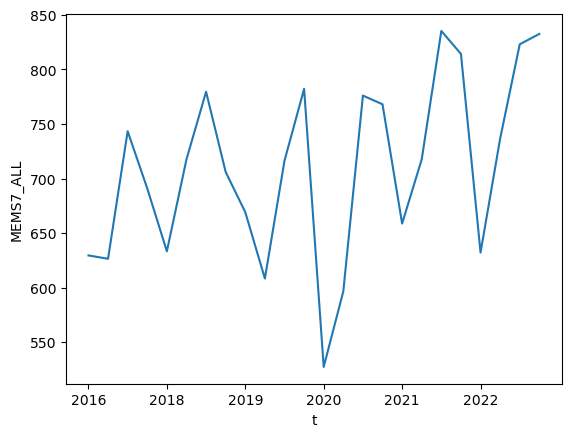

In [81]:

sns.lineplot(data=df_covid, x='t', y='MEMS7_ALL')
plt.xticks(ticks=[0,4,8,12,16,20], labels=['2016','2018','2019','2020','2021','2022'])
plt.show()


In [82]:
model = SARIMAX(df_covid['MEMS7_ALL'], order=(1,1,1), seasonal_order=(1,1,1,4))
results = model.fit()
forecast_values = results.forecast(16).values
df_covid_forecast = pd.DataFrame({'t': range(24, 40), 'MEMS7_ALL': forecast_values, 'type': 'forecast'})
df_covid['type'] = 'historical'

df_covid = pd.concat([df_covid, df_covid_forecast], ignore_index=True)

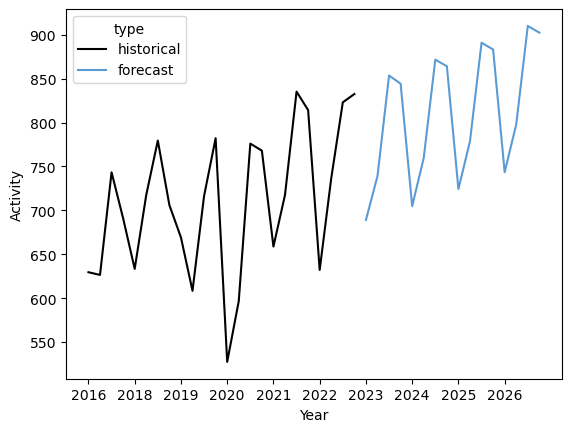

In [83]:
year_map = {0:'2016', 4:'2018', 8:'2019', 12:'2020', 16:'2021', 20:'2022', 24:'2023', 28:'2024', 32:'2025', 36:'2026'}
g = sns.lineplot(data=df_covid, x='t', y='MEMS7_ALL', hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
plt.xticks(ticks=[0,4,8,12,16,20,24,28,32,36], labels=['2016','2018','2019','2020','2021','2022','2023','2024','2025','2026'])
g.set(xlabel='Year', ylabel='Activity')
plt.show()

In [84]:
results = []

for borough in train.LA_Name.unique():
    X_train = train[train['LA_Name'] == borough]['t']
    y_train = train[train['LA_Name'] == borough]['MEMS7_ALL']
    X_test = test[test['LA_Name'] == borough]['t']
    y_test = test[test['LA_Name'] == borough]['MEMS7_ALL']

    X_train = X_train.values.reshape(-1, 1)
    
    model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,4))
    fitted_model = model.fit()
    forecast_values = fitted_model.forecast(20).values

    results.append([borough, forecast_values, y_test, X_test])



/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction

In [85]:
hist = train.groupby(['LA_Name', 't'])[['MEMS7_ALL']].mean(numeric_only=True).reset_index()
hist = hist.rename(columns={'LA_Name': 'borough', 'MEMS7_ALL': 'y_pred'})
hist['y_std'] = 0
hist['type'] = 'historical'

flat = []
for r in results: 
    for pred, t_val in zip(r[1], range(20, 40)):#zip(r[1], r[3].values):
        flat.append([r[0], t_val, pred, 0, 'forecast'])

forecast = pd.DataFrame(flat, columns=['borough','t','y_pred','y_std','type'])

combined_df = pd.concat([hist, forecast])

In [86]:
combined_df.head(50)

,borough,t,y_pred,y_std,type
0,Barking and Dagenham,0,534.356752,0,historical
1,Barking and Dagenham,1,533.700397,0,historical
2,Barking and Dagenham,2,701.299419,0,historical
3,Barking and Dagenham,3,517.017308,0,historical
4,Barking and Dagenham,4,646.483871,0,historical
5,Barking and Dagenham,5,614.730932,0,historical
6,Barking and Dagenham,6,578.411871,0,historical
7,Barking and Dagenham,7,460.940265,0,historical
8,Barking and Dagenham,8,791.838095,0,historical
9,Barking and Dagenham,9,485.130435,0,historical


In [87]:
combined_df['type'].value_counts()

type
historical    640
forecast      640
Name: count, dtype: int64

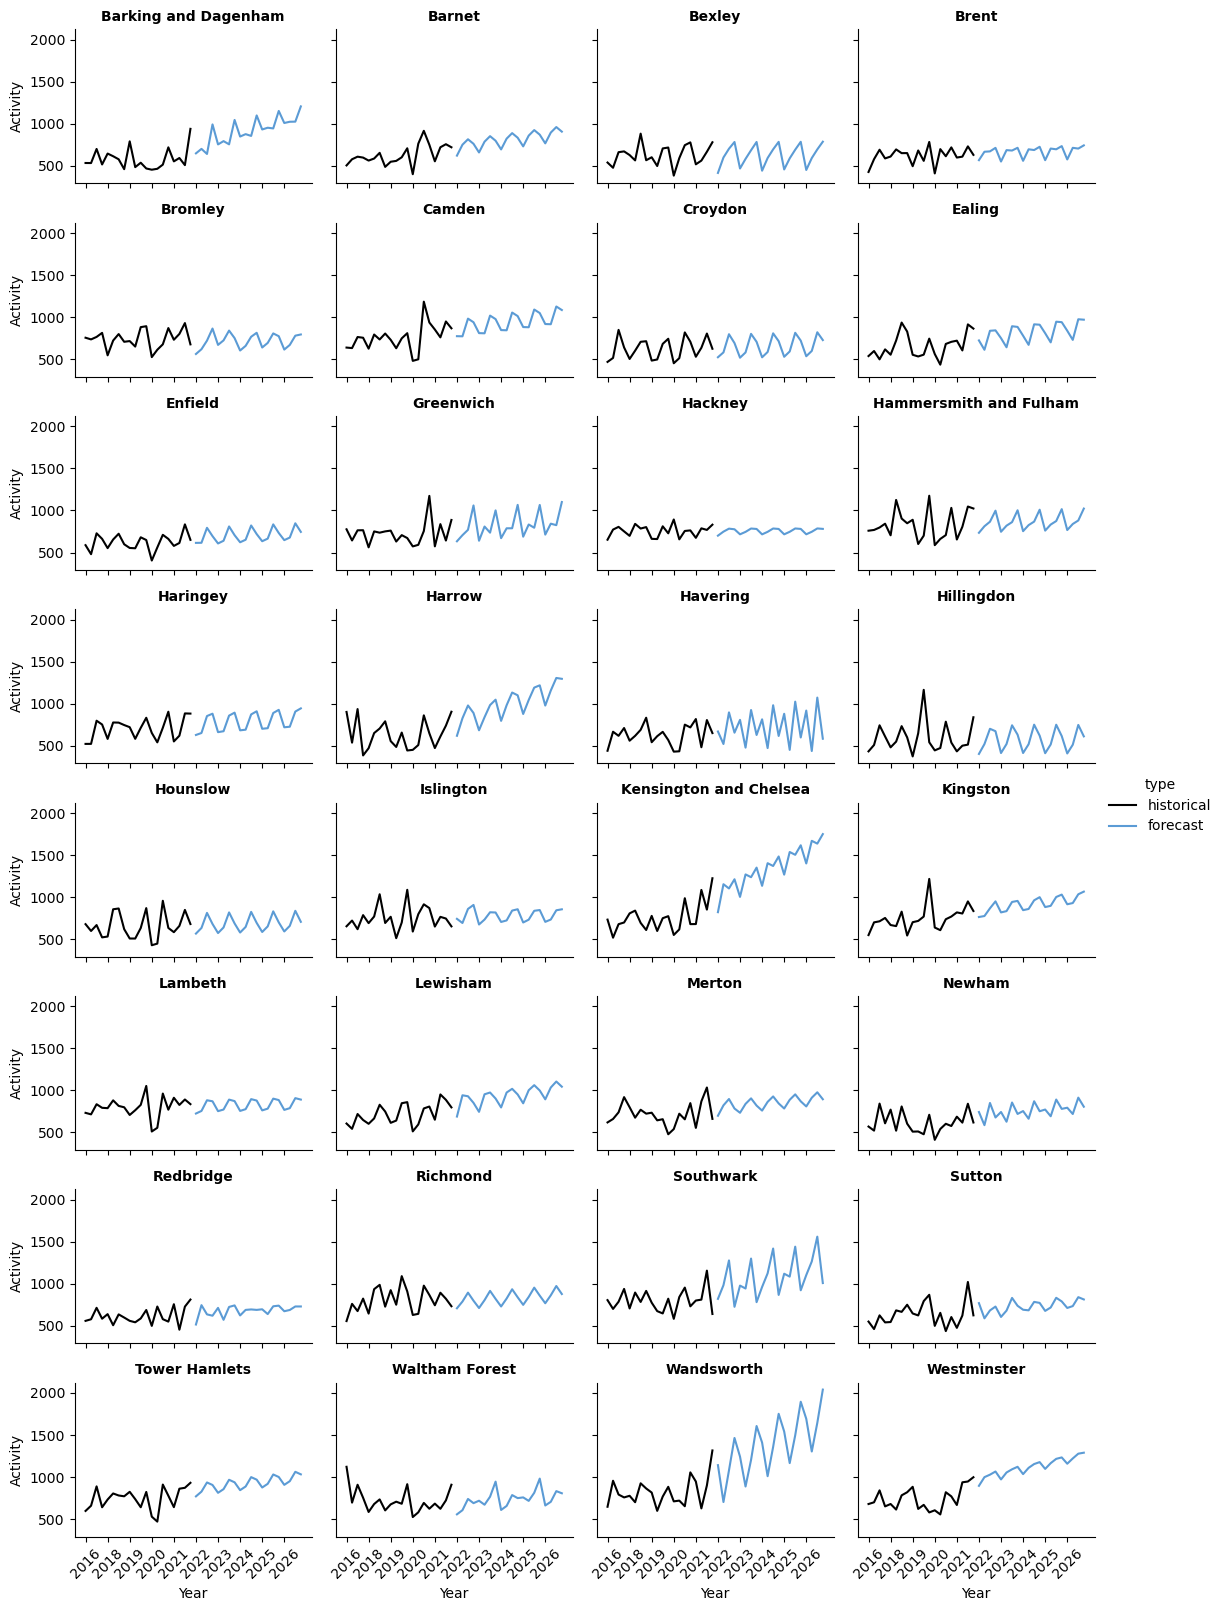

In [88]:
g = sns.relplot(kind='line', data=combined_df, x='t', y='y_pred', col='borough', col_wrap=4, height=2, aspect=1.4, hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
for borough, ax in g.axes_dict.items():
    borough_forecast = combined_df[combined_df['borough'] == borough]
    ax.errorbar(x=borough_forecast['t'], y=borough_forecast['y_pred'], yerr=borough_forecast['y_std'], fmt='none', alpha=0.3)
g.set(xticks=[0,4,8,12,16,20,24,28,32,36])
for ax in g.axes.flat: ax.set_xticklabels(['2016','2018','2019','2020','2021','2022','2023','2024','2025','2026'], rotation=45)
g.set_titles('{col_name}', weight='bold')
g.set(xlabel='Year', ylabel='Activity')
plt.show()